# pyGLAM: numerical study

Regenerates every number, table and figure of the numerical study in the paper
(`texto/`). Runs in a few minutes on a multi-core machine.

## **1. Libraries**

In [1]:
%matplotlib inline
import os
import sys
import time
from pathlib import Path

REPO = Path.cwd()
sys.path.insert(0, str(REPO))
# the parallel workers are fresh processes: they find pyglam through PYTHONPATH
os.environ['PYTHONPATH'] = os.pathsep.join(filter(None, [str(REPO), os.environ.get('PYTHONPATH')]))

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib as mpl
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

import pyglam as glam

mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.unicode_minus': False,
})

## **2. Config**

`n_rep` is what makes the convergence legible: a single fit at `N = 50` is dominated by sampling
noise, so every cell is summarised over independent replicates, by the median and the
interquartile range.

The seed of each replicate is drawn from a `SeedSequence` keyed by the target, `N` and the
replicate, but **not** by the parameterization, so FKML and RS are fitted to the *same* samples.
The comparison between the two is therefore paired, and any difference between them is a property
of the parameterization rather than of the draw.

The Student-$t$ with four degrees of freedom sits on the edge of the moment domain: its kurtosis is
infinite, which is exactly the case the study uses to separate the estimator from the family.

In [2]:
families = {
    'FKML': glam.GlamFKML,
    'RS':   glam.GlamRS,
}

targets = {
    'Normal':    st.norm(loc=0.0, scale=1.0),
    'Gumbel':    st.gumbel_r(loc=0.0, scale=1.0),
    'Uniform':   st.uniform(loc=0.0, scale=1.0),
    'Student-t': st.t(df=4, loc=0.0, scale=1.0),
    'Gamma':     st.gamma(a=2.0, scale=1.0),
    'Beta':      st.beta(a=2.0, b=5.0),
}

sizes      = (50, 200, 1000, 5000)   # sample sizes swept
n_rep      = 100                     # independent replicates per (family, distribution, N) cell
n_starts   = 15                      # pyGLAM multi-start attempts per fit
n_showcase = 1000                    # sample size used in the density figure
n_boot     = 2000                    # bootstrap resamples for the confidence interval of the slopes
base_seed  = 2024
n_jobs     = max(1, (os.cpu_count() or 2) - 1)

fig_dir    = REPO / 'texto'          # where the manuscript keeps its figures and tables
fig_format = 'pdf'
fig_dpi    = 300
fig_dir.mkdir(parents=True, exist_ok=True)

# categorical palette in fixed order, one marker per series as a secondary encoding so the
# figure survives greyscale printing
series  = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#9467bd', '#8c564b']
markers = ['o', 's', '^', 'D', 'v', 'p']
gray_f, gray_e, ink = '#d9d9d6', '#9c9a91', '#3d3d3a'

labels = {
    'pt': dict(dens='Densidade', x='$x$', sample='Amostra', fit='GLD ajustada',
               n='Tamanho amostral $N$', ks='Distância KS até a CDF alvo',
               names={'Normal': 'Normal', 'Gumbel': 'Gumbel', 'Uniform': 'Uniforme',
                      'Student-t': 't-Student ($\\nu=4$)', 'Gamma': 'Gama', 'Beta': 'Beta'}),
    'en': dict(dens='Density', x='$x$', sample='Sample', fit='Fitted GLD',
               n='Sample size $N$', ks='KS distance to target CDF',
               names={'Normal': 'Normal', 'Gumbel': 'Gumbel', 'Uniform': 'Uniform',
                      'Student-t': 'Student-$t$ ($\\nu=4$)', 'Gamma': 'Gamma', 'Beta': 'Beta'}),
}


def cell_seed(name, n, rep):
    # an integer seed keyed by target, sample size and replicate; independent across cells
    key = [base_seed, list(targets).index(name), n, rep]
    return int(np.random.SeedSequence(key).generate_state(1)[0])


print(f'{len(families)} parameterizations x {len(targets)} targets x {len(sizes)} sizes x {n_rep} reps'
      f' = {len(families) * len(targets) * len(sizes) * n_rep} fits on {n_jobs} workers')

2 parameterizations x 6 targets x 4 sizes x 100 reps = 4800 fits on 31 workers


## **3. Fitting and scoring one sample**

### 3.1 Screening the fitted parameters

`fit_lambdas` reports optimizer termination, not distributional validity. Four-moment matching
admits several roots, and some of them have a quantile function that is not monotone: the
"distribution" runs backwards. Those fits reproduce the four moments and are still returned with
`success=True`.

`check_model` is the screen: it evaluates the quantile function on a dense probability grid and
requires it to be finite and non-decreasing. It returns the grid of quantiles as well, because the
analytical KS distance is computed from exactly the same evaluation.

In [3]:
U_GRID = np.linspace(1e-6, 1.0 - 1e-6, 4001)


def check_model(model, u=U_GRID):
    # Evaluate the quantile function on a probability grid and check it is a distribution.
    # Returns (valid, x) with the validity flag and the quantiles, None when unusable.
    try:
        x = np.asarray(model.ppf(u), dtype=float)
    except Exception:
        return False, None

    if not np.all(np.isfinite(x)):
        return False, None

    # a strictly decreasing stretch anywhere means the parameters are not a distribution;
    # the tolerance absorbs round-off in the quantile evaluation, not a real decrease
    return bool(np.all(np.diff(x) >= -1e-10)), x


def ks_analytic(dist, x, u=U_GRID):
    # Supremum distance between the fitted GLD CDF and the analytical target CDF.
    # Parameterising by u turns sup_x |F_gld(x) - F_target(x)| into sup_u |u - F_target(Q(u))|,
    # which needs no root finding. The two extra terms cover the probability mass the target
    # places outside a compact GLD support, where F_gld is pinned at 0 or 1.
    cdf_target = dist.cdf(np.asarray(x, dtype=float))
    return float(max(np.max(np.abs(cdf_target - u)), cdf_target[0], 1.0 - cdf_target[-1]))

### 3.2 Fit and score one sample, on `pyglam` alone

`evaluate_gld_fit` draws one sample from the target, fits a GLD to it with `fit_lambdas`, screens
the result, and scores it two ways: against the **analytical** target through `ks_analytic`, and
against a **large reference sample** from the target through `pyglam.Performance`. Both the
reference and the GLD sample are drawn with their tails intact, so FKML and RS are compared on
equal terms.

The quantile errors are kept as plain NumPy: `Performance`'s own relative error divides by the
reference quantile itself, which blows up for a target like the Normal whose median sits at zero.
Normalising by the spread between $P_5$ and $P_{95}$ keeps it well-behaved for every target.

In [4]:
def evaluate_gld_fit(name, n, rep, family, n_ref=20000, n_grid=400):
    # Draw one sample from a target distribution, fit a GLD to it and score the fit.
    dist   = targets[name]
    cls    = families[family]
    seed   = cell_seed(name, n, rep)
    rng    = np.random.default_rng(seed)
    sample = dist.rvs(size=n, random_state=rng)

    t0      = time.perf_counter()
    sol     = cls().fit_lambdas(sample, method='least_squares', n_starts=n_starts, seed=seed)
    elapsed = time.perf_counter() - t0

    lambdas = np.asarray(sol.x, dtype=float)
    fitted  = cls(*lambdas)

    candidates = np.asarray(sol.candidates, dtype=float)
    invalid    = ~np.asarray(sol.monotone, dtype=bool)
    row = {'Family': family, 'Distribution': name, 'N': n, 'rep': rep,
           'lambda 1': lambdas[0], 'lambda 2': lambdas[1],
           'lambda 3': lambdas[2], 'lambda 4': lambdas[3],
           'success': bool(sol.success), 'fit time (s)': elapsed,
           'sample kurtosis': float(st.kurtosis(sample, fisher=False)),
           'candidates': int(candidates.shape[0]),
           'candidates invalid': int(invalid.sum()),
           'invalid with lambda2 < 0': int((invalid & (candidates[:, 1] < 0)).sum())}

    valid, x_grid = check_model(fitted)
    row['valid'] = valid

    nan_cols = ['KS', 'KS 2-sample', 'KS test (N)', 'p-value', 'KL', 'Wasserstein', 'R2 (PDF)',
                'err P5 (%)', 'err P50 (%)', 'err P95 (%)']
    if not valid:
        # an invalid quantile function makes every downstream metric meaningless, not merely bad
        row.update({column: np.nan for column in nan_cols})
        return row

    row['KS'] = ks_analytic(dist, x_grid)

    ref_n      = max(n, n_ref)
    dist_ref   = dist.rvs(size=ref_n, random_state=rng)
    gld_sample = fitted.rvs(size=ref_n, random_state=seed, quantile_trim=0.0)
    perf       = glam.Performance(n_grid=n_grid).performance(dist_ref, gld_sample)

    row['KS 2-sample'] = perf['ks_statistic']
    row['KL']          = perf['kl_divergence']
    row['Wasserstein'] = perf['wasserstein']
    row['R2 (PDF)']    = perf['r2_pdf']

    # The test above runs on n_ref draws per side, so it asks whether the GLD *is* the target.
    # It is not, and at that scale the test rejects essentially always. Re-running it at the
    # sample size actually available is the question a practitioner asks of their own data.
    test_target = dist.rvs(size=n, random_state=rng)
    test_gld    = fitted.rvs(size=n, random_state=seed + 1, quantile_trim=0.0)
    ks_res      = st.ks_2samp(test_target, test_gld)
    row['KS test (N)'] = float(ks_res.statistic)
    row['p-value']     = float(ks_res.pvalue)

    quantiles = np.array([0.05, 0.50, 0.95])
    spread    = dist.ppf(0.95) - dist.ppf(0.05)
    err_q     = np.abs(fitted.ppf(quantiles) - dist.ppf(quantiles)) / spread * 100.0
    row['err P5 (%)'], row['err P50 (%)'], row['err P95 (%)'] = err_q

    return row

## **4. Run the study**

In [5]:
tasks = [(name, n, rep, family) for family in families for name in targets
         for n in sizes for rep in range(n_rep)]

t0   = time.perf_counter()
rows = Parallel(n_jobs=n_jobs, batch_size=8)(delayed(evaluate_gld_fit)(*task) for task in tasks)
raw  = pd.DataFrame(rows)

print(f'{len(raw)} fits completed in {time.perf_counter() - t0:.1f} s of wall time')

4800 fits completed in 443.4 s of wall time


## **5. Validity and cost of the fits**

- `success (%)` is what the optimizer reports; it says nothing about validity;
- `candidates valid (%)` is the share of the multi-start candidates that are distributions at all;
- `valid (%)` is the share of the fits returned by the library that are distributions;
- the fit time is measured per fit, inside one worker process.

In [6]:
validity = (raw.groupby(['Family', 'Distribution'], as_index=False, sort=False)
               .agg(fits=('valid', 'size'),
                    success_rate=('success', 'mean'),
                    valid_rate=('valid', 'mean'),
                    n_cand=('candidates', 'sum'),
                    n_bad=('candidates invalid', 'sum'),
                    n_bad_l2=('invalid with lambda2 < 0', 'sum'),
                    time_mean=('fit time (s)', 'mean'),
                    time_sd=('fit time (s)', 'std')))

validity['success (%)']          = validity.pop('success_rate') * 100
validity['valid (%)']            = validity.pop('valid_rate') * 100
validity['candidates valid (%)'] = 100 * (1 - validity['n_bad'] / validity['n_cand'])

display(validity.round(3))
print(f"fitting time: {raw['fit time (s)'].sum():.1f} s in total, "
      f"{raw['fit time (s)'].mean():.3f} +/- {raw['fit time (s)'].std():.3f} s per fit")
display(raw.groupby('Family')['fit time (s)'].agg(['mean', 'std', 'median', 'max']).round(3))

,Family,Distribution,fits,n_cand,n_bad,n_bad_l2,time_mean,time_sd,success (%),valid (%),candidates valid (%)
0,FKML,Normal,400,6000,0,0,0.186,0.344,100.0,100.0,100.000
1,FKML,Gumbel,400,6000,0,0,0.162,0.106,100.0,100.0,100.000
2,FKML,Uniform,400,6000,24,23,2.287,2.009,100.0,100.0,99.600
3,FKML,Student-t,400,6000,1,1,0.197,0.135,100.0,100.0,99.983
4,FKML,Gamma,400,6000,1,1,0.328,0.445,100.0,100.0,99.983
5,FKML,Beta,400,6000,3,3,0.259,0.576,100.0,100.0,99.950
6,RS,Normal,400,6000,0,0,0.205,0.106,100.0,100.0,100.000
7,RS,Gumbel,400,6000,0,0,0.302,0.145,100.0,100.0,100.000
8,RS,Uniform,400,6000,0,0,0.262,0.116,100.0,100.0,100.000
9,RS,Student-t,400,6000,0,0,0.282,0.144,100.0,100.0,100.000


fitting time: 2038.7 s in total, 0.425 +/- 0.849 s per fit


,mean,std,median,max
Family,,,,
FKML,0.57,1.173,0.175,8.391
RS,0.28,0.154,0.251,1.694


## **6. Summary**

Medians over the replicates, computed on the **valid** fits only, with the interquartile range of
the KS distance; `invalid (%)` carries the discarded fraction so the two are never read apart. `KS`
is the distance to the analytical target, `KS 2-sample` its sample-based counterpart at reference
scale, and `rejection rate (%)` counts how often the test at size $N$ rejects at the 5% level.

In [7]:
metric_cols = ['KS', 'KS 2-sample', 'KS test (N)', 'KL', 'Wasserstein', 'R2 (PDF)',
               'err P5 (%)', 'err P50 (%)', 'err P95 (%)', 'p-value']

keys = ['Family', 'Distribution', 'N']
good = raw[raw['valid']]

summary = good.groupby(keys, as_index=False, sort=False)[metric_cols].median()
counts = raw.groupby(keys, as_index=False, sort=False).agg(invalid=('valid', lambda v: 100.0 * (~v).mean()))
reject  = (good.assign(rej=good['p-value'] < 0.05)
               .groupby(keys, as_index=False, sort=False).agg(rej=('rej', 'mean')))

q = good.groupby(keys, sort=False)['KS'].quantile([0.25, 0.75]).unstack().reset_index()
q.columns = keys + ['KS Q1', 'KS Q3']
summary = summary.merge(q, on=keys).merge(counts, on=keys).merge(reject, on=keys)
summary['KS IQR'] = summary['KS Q3'] - summary['KS Q1']
summary['rejection rate (%)'] = summary.pop('rej') * 100
summary = summary.rename(columns={'invalid': 'invalid (%)'})

summary.round(4)

,Family,Distribution,N,KS,KS 2-sample,KS test (N),KL,Wasserstein,R2 (PDF),err P5 (%),err P50 (%),err P95 (%),p-value,KS Q1,KS Q3,invalid (%),KS IQR,rejection rate (%)
0,FKML,Normal,50,0.0562,0.0574,0.1800,0.0651,0.1307,0.9621,4.4788,3.1435,4.7403,0.3959,0.0408,0.0816,0.0,0.0408,7.0
1,FKML,Normal,200,0.0320,0.0345,0.0850,0.0127,0.0742,0.9895,2.8441,1.5412,2.5686,0.4663,0.0214,0.0423,0.0,0.0209,7.0
2,FKML,Normal,1000,0.0137,0.0174,0.0380,0.0029,0.0334,0.9970,0.9785,0.6799,1.1043,0.4660,0.0093,0.0178,0.0,0.0086,8.0
3,FKML,Normal,5000,0.0067,0.0117,0.0171,0.0015,0.0196,0.9984,0.4597,0.3202,0.4903,0.4578,0.0040,0.0089,0.0,0.0049,3.0
4,FKML,Gumbel,50,0.0758,0.0768,0.1800,0.1196,0.2019,0.9312,3.5241,3.4831,7.9892,0.3959,0.0627,0.0960,0.0,0.0334,9.0
5,FKML,Gumbel,200,0.0458,0.0467,0.0950,0.0482,0.0992,0.9701,2.0944,1.7627,4.4600,0.3281,0.0312,0.0626,0.0,0.0314,15.0
6,FKML,Gumbel,1000,0.0220,0.0238,0.0420,0.0161,0.0512,0.9914,0.8682,0.7280,1.9065,0.3411,0.0151,0.0280,0.0,0.0128,18.0
7,FKML,Gumbel,5000,0.0146,0.0176,0.0240,0.0113,0.0375,0.9944,0.4065,0.3120,0.9840,0.1123,0.0121,0.0180,0.0,0.0059,26.0
8,FKML,Uniform,50,0.0586,0.0603,0.1600,0.0132,0.0320,-1.0000,2.3827,4.0725,2.1507,0.5487,0.0363,0.0765,0.0,0.0403,10.0
9,FKML,Uniform,200,0.0322,0.0339,0.0900,0.0043,0.0181,0.2316,1.1058,2.3616,1.0468,0.3935,0.0233,0.0450,0.0,0.0217,7.0


### 6.1 Convergence rate

The error of a moment-based fit has a **sampling** part, from estimating the first four moments on
a finite sample, which decays at the theoretical rate $N^{-1/2}$, and a **structural** part, from
the GLD family not containing the target exactly, which does not depend on $N$.

The slope of $\log \mathrm{KS}$ against $\log N$, fitted to the median KS of each cell, tells them
apart. A slope near $-0.5$ with a high $R^2$ means the error is sampling; a slope near zero means a
structural floor dominates. The 95% confidence interval of the slope comes from a bootstrap that
resamples the replicates of every cell independently.

In [8]:
def slope_and_r2(x, y):
    a, b = np.polyfit(x, y, 1)
    r2   = 1 - ((y - (a * x + b)) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return a, r2


boot_rng = np.random.default_rng(base_seed)
rates = []
for family in families:
    for name in targets:
        cell = good[(good['Family'] == family) & (good['Distribution'] == name)]
        ks_by_n = [cell.loc[cell['N'] == n, 'KS'].to_numpy() for n in sizes]
        x = np.log(np.asarray(sizes, dtype=float))
        y = np.log([np.median(v) for v in ks_by_n])
        a, r2 = slope_and_r2(x, y)

        # bootstrap: resample the replicates of every N independently, refit the slope
        med = np.column_stack([np.median(v[boot_rng.integers(0, v.size, (n_boot, v.size))], axis=1)
                               for v in ks_by_n])
        ly  = np.log(med)
        xc  = x - x.mean()
        boot_slopes = (ly - ly.mean(axis=1, keepdims=True)) @ xc / (xc @ xc)
        lo, hi = np.percentile(boot_slopes, [2.5, 97.5])

        rates.append({'Family': family, 'Distribution': name, 'slope': a,
                      'CI low': lo, 'CI high': hi, 'R2': r2,
                      'regime': 'sampling-limited' if a < -0.45 else
                                ('mixed' if a < -0.30 else 'structural floor')})

rates = pd.DataFrame(rates)
rates.round(3)

,Family,Distribution,slope,CI low,CI high,R2,regime
0,FKML,Normal,-0.467,-0.516,-0.436,0.998,sampling-limited
1,FKML,Gumbel,-0.367,-0.387,-0.344,0.988,mixed
2,FKML,Uniform,-0.455,-0.495,-0.409,0.993,sampling-limited
3,FKML,Student-t,-0.396,-0.425,-0.362,0.997,mixed
4,FKML,Gamma,-0.193,-0.228,-0.174,0.952,structural floor
5,FKML,Beta,-0.421,-0.448,-0.394,0.995,mixed
6,RS,Normal,-0.484,-0.522,-0.434,0.999,sampling-limited
7,RS,Gumbel,-0.383,-0.410,-0.354,0.990,mixed
8,RS,Uniform,-0.459,-0.499,-0.413,0.993,sampling-limited
9,RS,Student-t,-0.363,-0.400,-0.326,0.992,mixed


### 6.2 Fitted parameters and sample kurtosis

Median fitted parameters by sample size, and the sample kurtosis of the targets. For the
Student-$t$ with four degrees of freedom the population kurtosis is infinite, so the sample
kurtosis does not converge and the moments being matched move with $N$.

In [9]:
params = (good.groupby(['Family', 'Distribution', 'N'], sort=False)
              [['lambda 1', 'lambda 2', 'lambda 3', 'lambda 4']]
              .agg(['median', lambda v: v.quantile(0.75) - v.quantile(0.25)]))
display(params.round(3))

kurt = (raw[raw['Family'] == 'FKML'].groupby(['Distribution', 'N'], sort=False)['sample kurtosis']
           .agg(['mean', 'median']).unstack('N'))
display(kurt.round(2))

lambda 1            lambda 2            lambda 3  \
                           median <lambda_0>   median <lambda_0>   median   
Family Distribution N                                                       
FKML   Normal       50     -0.002      0.229    1.326      0.314    0.221   
                    200     0.007      0.101    1.436      0.228    0.160   
                    1000    0.006      0.044    1.464      0.085    0.139   
                    5000    0.000      0.024    1.457      0.040    0.137   
       Gumbel       50      0.181      0.357    0.912      0.287    0.736   
                    200     0.224      0.180    1.045      0.189    0.619   
                    1000    0.263      0.068    1.133      0.111    0.491   
                    5000    0.278      0.027    1.149      0.067    0.466   
       Uniform      50      0.502      0.117    1.747      1.216    1.077   
                    200     0.505      0.072    1.833      0.782    1.064   
                    1000    0.499      0.028    1.987      0.382    1.010   
                    5000    0.500      0.011    2.009      0.156    0.987   
       Student-t    50      0.013      0.251    1.209      0.290    0.081   
                    200    -0.001      0.162    1.426      0.211   -0.020   
                    1000   -0.014      0.079    1.569      0.148   -0.086   
                    5000   -0.001      0.040    1.695      0.123   -0.141   
       Gamma        50      1.257      0.705    0.692      0.300    1.898   
                    200     1.359      0.274    0.827      0.192    1.199   
                    1000    1.452      0.132    0.892      0.137    0.979   
                    5000    1.461      0.056    0.901      0.053    0.943   
       Beta         50      0.244      0.054    6.364      2.401    0.758   
                    200     0.254      0.023    7.043      1.016    0.607   
                    1000    0.253      0.012    6.967      0.533    0.614   
                    5000    0.253      0.004    7.040      0.215    0.601   
RS     Normal       50      0.005      0.783    0.239      0.124    0.137   
                    200     0.016      0.302    0.221      0.077    0.143   
                    1000    0.003      0.110    0.205      0.051    0.140   
                    5000    0.010      0.054    0.202      0.017    0.139   
       Gumbel       50     -0.378      1.218    0.164      0.108    0.037   
                    200    -0.295      0.313    0.100      0.096    0.023   
                    1000   -0.209      0.162    0.042      0.065    0.013   
                    5000   -0.205      0.079    0.031      0.028    0.010   
       Uniform      50      0.490      0.071    1.886      0.909    1.101   
                    200     0.499      0.026    1.980      0.096    1.053   
                    1000    0.502      0.012    1.995      0.097    1.010   
                    5000    0.500      0.005    1.995      0.029    0.985   
       Student-t    50      0.025      0.832    0.061      0.149    0.049   
                    200    -0.044      0.313   -0.087      0.149   -0.055   
                    1000   -0.026      0.171   -0.188      0.105   -0.108   
                    5000    0.003      0.103   -0.250      0.097   -0.140   
       Gamma        50      3.186      3.069    0.192      0.159    3.081   
                    200     3.866      3.951    0.203      0.121   19.369   
                    1000    4.091      3.636    0.211      0.173   23.813   
                    5000    4.321      3.514    0.230      0.175   31.009   
       Beta         50      0.143      0.104    1.477      0.655    0.045   
                    200     0.144      0.036    1.363      0.271    0.040   
                    1000    0.142      0.018    1.350      0.137    0.041   
                    5000    0.144      0.007    1.332      0.061    0.042   

                                    lambda 4             
                         <lambda_0>   m

mean                     median                   
N             50    200    1000   5000   50    200   1000   5000
Distribution                                                    
Normal        2.85  2.95   3.00   2.99   2.78  2.90  2.98   2.97
Gumbel        4.21  4.94   5.59   5.36   3.54  4.52  5.16   5.27
Uniform       1.83  1.81   1.80   1.80   1.83  1.80  1.80   1.80
Student-t     5.12  7.71  12.14  13.90   4.09  5.61  7.99  10.24
Gamma         4.65  5.59   6.06   5.97   4.00  5.33  5.73   5.91
Beta          2.89  2.86   2.86   2.88   2.76  2.85  2.84   2.87

## **7. Density fits**

One row per target, one column per parameterization, so the figure fits a portrait page. Both
columns are fitted to the same sample of each target.

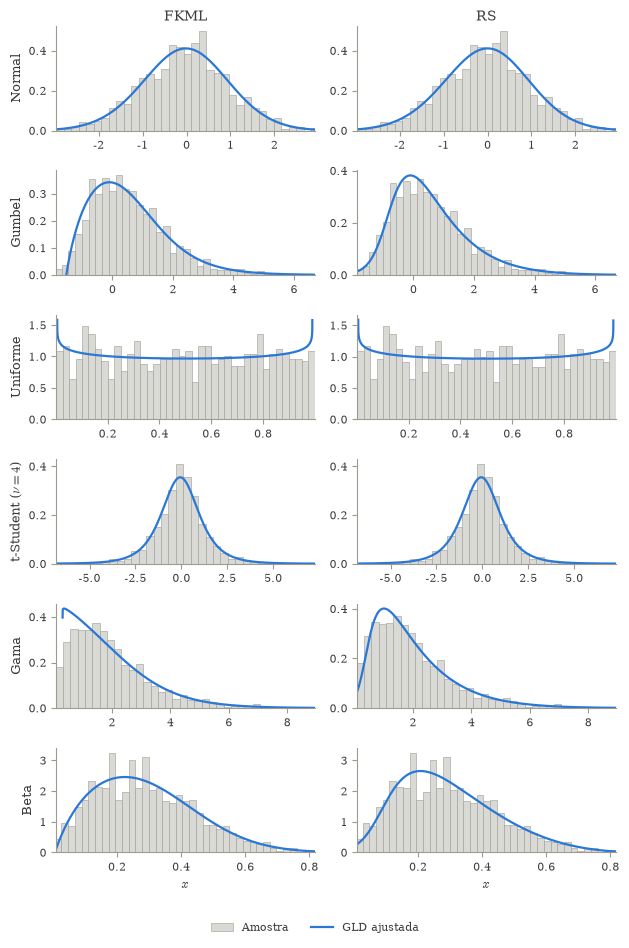

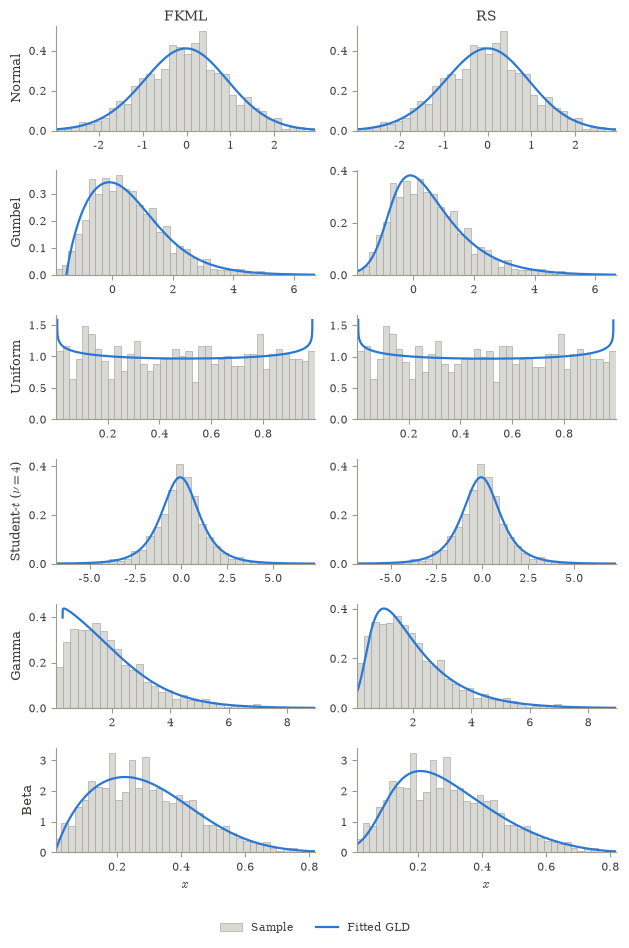

In [10]:
def style_axis(ax):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color(gray_e)
        ax.spines[s].set_linewidth(0.8)
    ax.tick_params(colors=ink, labelsize=8, width=0.8, color=gray_e)


def plot_fits(lang, n=n_showcase, seed=42, save=True):
    L = labels[lang]
    fig, axes = plt.subplots(len(targets), len(families), figsize=(6.4, 1.55 * len(targets)),
                             squeeze=False)

    for row, (name, dist) in enumerate(targets.items()):
        sample = dist.rvs(size=n, random_state=np.random.default_rng(seed))
        for col, (family, cls) in enumerate(families.items()):
            ax      = axes[row][col]
            lambdas = cls().fit_lambdas(sample, method='least_squares', n_starts=n_starts, seed=seed).x
            fitted  = cls(*lambdas)
            valid, x_u = check_model(fitted)

            ax.hist(sample, bins=40, density=True, color=gray_f, edgecolor=gray_e,
                    linewidth=0.4, label=L['sample'])
            if valid:
                ax.plot(x_u, fitted.pdf(x_u), color=series[0], linewidth=1.6, label=L['fit'])

            if row == 0:
                ax.set_title(family, fontsize=10, color=ink, pad=4)
            if col == 0:
                ax.set_ylabel(L['names'][name], fontsize=9, color=ink)
            if row == len(targets) - 1:
                ax.set_xlabel(L['x'], fontsize=9, color=ink)
            ax.set_xlim(np.percentile(sample, 0.1), np.percentile(sample, 99.9))
            style_axis(ax)

    h, lb = axes[0][0].get_legend_handles_labels()
    fig.legend(h, lb, frameon=False, fontsize=8, labelcolor=ink, ncol=2,
               loc='lower center', bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=(0, 0.02, 1, 1))

    if save:
        fig.savefig(fig_dir / f'z_pyglam_fits_{lang}.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    return fig


for lang in ('pt', 'en'):
    plot_fits(lang)
plt.show()

## **8. Convergence of the fit**

Median KS distance to the **analytical** target CDF against sample size, on logarithmic axes, with
the interquartile range of the replicates as a band. One panel per parameterization, stacked so the
figure fits a portrait page. The dashed guide has slope $-1/2$, the theoretical sampling rate; a
series parallel to it is sampling-limited.

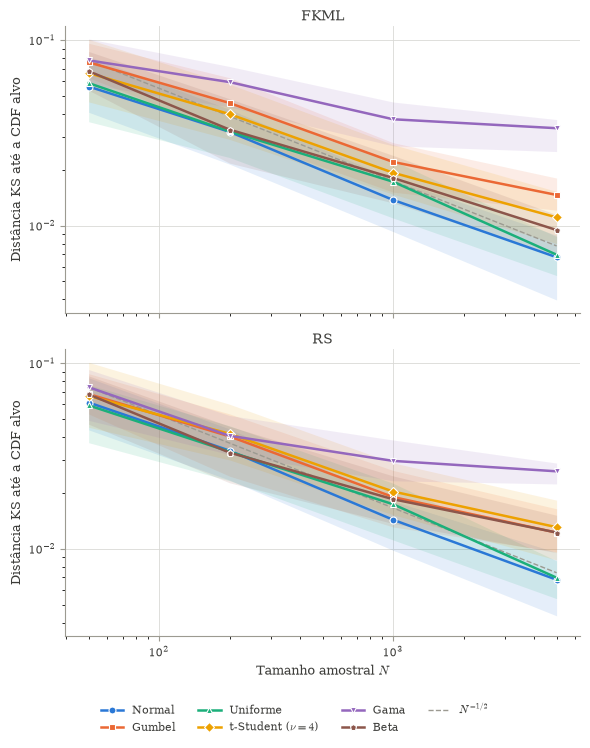

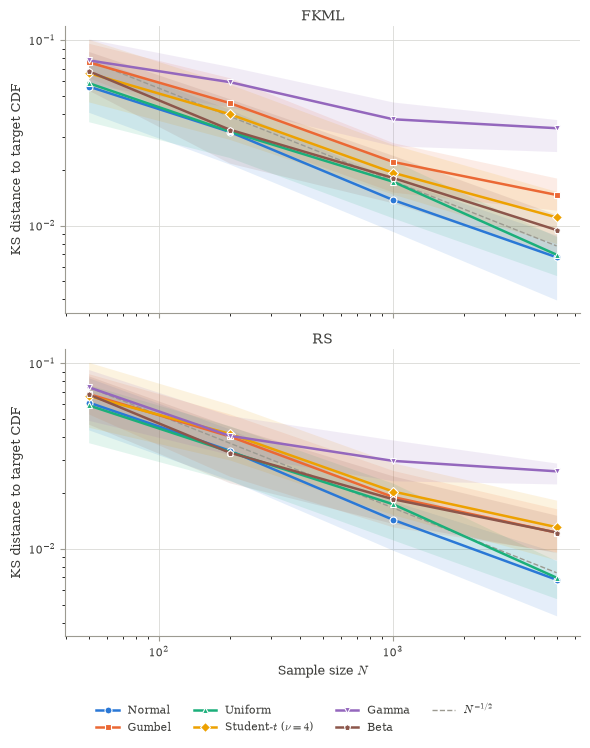

In [11]:
def plot_convergence(lang, save=True):
    L = labels[lang]
    fig, axes = plt.subplots(len(families), 1, figsize=(6.0, 3.6 * len(families)),
                             sharex=True, sharey=True, squeeze=False)

    for panel, family in enumerate(families):
        ax = axes[panel][0]
        for i, name in enumerate(targets):
            d = summary[(summary['Family'] == family) & (summary['Distribution'] == name)].sort_values('N')
            ax.fill_between(d['N'], d['KS Q1'], d['KS Q3'], color=series[i], alpha=0.12, linewidth=0)
            ax.plot(d['N'], d['KS'], color=series[i], linewidth=1.8, marker=markers[i],
                    markersize=5, markeredgecolor='white', markeredgewidth=0.8,
                    label=L['names'][name])

        # slope -1/2 guide, anchored on the smallest N of the panel
        anchor = summary[(summary['Family'] == family) & (summary['N'] == min(sizes))]['KS'].max()
        n_ref  = np.array([min(sizes), max(sizes)], dtype=float)
        ax.plot(n_ref, anchor * (n_ref / min(sizes)) ** -0.5, color=gray_e, linewidth=1.0,
                linestyle='--', zorder=1, label=r'$N^{-1/2}$')

        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_title(family, fontsize=10, color=ink, pad=4)
        ax.set_ylabel(L['ks'], fontsize=9, color=ink)
        ax.grid(True, which='major', color=gray_f, linewidth=0.6, zorder=0)
        ax.set_axisbelow(True)
        style_axis(ax)

    axes[-1][0].set_xlabel(L['n'], fontsize=9, color=ink)
    h, lb = axes[0][0].get_legend_handles_labels()
    fig.legend(h, lb, frameon=False, fontsize=8, labelcolor=ink, ncol=4,
               loc='lower center', bbox_to_anchor=(0.5, -0.04))
    fig.tight_layout(rect=(0, 0.03, 1, 1))

    if save:
        fig.savefig(fig_dir / f'z_pyglam_convergence_{lang}.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    return fig


for lang in ('pt', 'en'):
    plot_convergence(lang)
plt.show()

## **9. LaTeX tables**

Written straight into `texto/`, so the manuscript can `\input` them and never holds a number that
was copied by hand.

In [12]:
def num(value, decimals, lang='pt'):
    # Format a number with the decimal separator the target language uses
    if not np.isfinite(value):
        return '---'
    text = f'{value:.{decimals}f}'
    return text.replace('.', ',') if lang == 'pt' else text


def num_n(value, lang='pt'):
    # Format a sample size with the thousands separator the target language uses
    text = f'{int(value):,}'
    return text.replace(',', '.') if lang == 'pt' else text


def drop_last_terminator(body):
    # A fragment that ends in a row terminator cannot be \input inside a tabular: TeX reports a
    # misplaced \noalign at the following rule. The manuscript supplies the terminator instead.
    body = body.rstrip()
    return body[:-2].rstrip() if body.endswith('\\\\') else body


def latex_metrics(family, lang='pt'):
    # Body of the per-parameterization metrics table: medians over the replicates
    names, lines = labels[lang]['names'], []
    for name in targets:
        d = summary[(summary['Family'] == family) & (summary['Distribution'] == name)].sort_values('N')
        for _, r in d.iterrows():
            label = names[name] if r['N'] == d['N'].iloc[0] else ''
            cells = [num(r['KS'], 4, lang), num(r['KS IQR'], 4, lang), num(r['KL'], 4, lang),
                     num(r['Wasserstein'], 4, lang), num(r['err P5 (%)'], 2, lang),
                     num(r['err P50 (%)'], 2, lang), num(r['err P95 (%)'], 2, lang)]
            lines.append(f"{label} & {num_n(r['N'], lang)} & " + ' & '.join(cells) + r' \\')
        lines.append(r'\midrule')
    return drop_last_terminator('\n'.join(lines[:-1]))


def latex_rates(lang='pt'):
    # Body of the convergence-rate table, with the bootstrap confidence interval of the slope
    names  = labels[lang]['names']
    regime = {'pt': {'sampling-limited': 'amostral', 'mixed': 'misto',
                     'structural floor': 'patamar estrutural'},
              'en': {k: k for k in ('sampling-limited', 'mixed', 'structural floor')}}[lang]
    sep, lines = ('; ' if lang == 'pt' else ', '), []
    for family in families:
        d = rates[rates['Family'] == family]
        for i, (_, r) in enumerate(d.iterrows()):
            ci = f"$[{num(r['CI low'], 3, lang)}{sep}{num(r['CI high'], 3, lang)}]$"
            lines.append(f"{family if i == 0 else ''} & {names[r['Distribution']]} & "
                         f"${num(r['slope'], 3, lang)}$ & {ci} & ${num(r['R2'], 3, lang)}$ & "
                         f"{regime[r['regime']]}" + r' \\')
    return drop_last_terminator('\n'.join(lines))


def latex_validity(lang='pt'):
    # Body of the validity and cost table
    names, lines = labels[lang]['names'], []
    for family in families:
        d = validity[validity['Family'] == family]
        for i, (_, r) in enumerate(d.iterrows()):
            cells = [str(int(r['fits'])), num(r['candidates valid (%)'], 1, lang),
                     num(r['valid (%)'], 1, lang), num(r['time_mean'], 2, lang),
                     num(r['time_sd'], 2, lang)]
            lines.append(f"{family if i == 0 else ''} & {names[r['Distribution']]} & "
                         + ' & '.join(cells) + r' \\')
    return drop_last_terminator('\n'.join(lines))


for lang in ('pt', 'en'):
    bodies = {f'metrics_{f.lower()}': latex_metrics(f, lang) for f in families}
    bodies.update(rates=latex_rates(lang), validity=latex_validity(lang))
    for stem, body in bodies.items():
        (fig_dir / f'z_tab_pyglam_{stem}_{lang}.tex').write_text(body + '\n', encoding='utf-8')
    print(f'--- {lang} ---'); print(bodies['rates']); print()

# raw results next to the notebook, so every number in the paper can be traced back
for stem, frame in (('raw', raw), ('summary', summary), ('rates', rates), ('validity', validity)):
    frame.to_csv(REPO / f'00_pyglam_test_{stem}.csv', index=False)

--- pt ---
FKML & Normal & $-0,467$ & $[-0,516; -0,436]$ & $0,998$ & amostral \\
 & Gumbel & $-0,367$ & $[-0,387; -0,344]$ & $0,988$ & misto \\
 & Uniforme & $-0,455$ & $[-0,495; -0,409]$ & $0,993$ & amostral \\
 & t-Student ($\nu=4$) & $-0,396$ & $[-0,425; -0,362]$ & $0,997$ & misto \\
 & Gama & $-0,193$ & $[-0,228; -0,174]$ & $0,952$ & patamar estrutural \\
 & Beta & $-0,421$ & $[-0,448; -0,394]$ & $0,995$ & misto \\
RS & Normal & $-0,484$ & $[-0,522; -0,434]$ & $0,999$ & amostral \\
 & Gumbel & $-0,383$ & $[-0,410; -0,354]$ & $0,990$ & misto \\
 & Uniforme & $-0,459$ & $[-0,499; -0,413]$ & $0,993$ & amostral \\
 & t-Student ($\nu=4$) & $-0,363$ & $[-0,400; -0,326]$ & $0,992$ & misto \\
 & Gama & $-0,221$ & $[-0,239; -0,192]$ & $0,893$ & patamar estrutural \\
 & Beta & $-0,369$ & $[-0,392; -0,338]$ & $0,977$ & misto

--- en ---
FKML & Normal & $-0.467$ & $[-0.516, -0.436]$ & $0.998$ & sampling-limited \\
 & Gumbel & $-0.367$ & $[-0.387, -0.344]$ & $0.988$ & mixed \\
 & Uniform & $-0.